<a href="https://colab.research.google.com/github/DinRazar/ispm/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №5. Архитектуры CNN и Transfer Learning.ipynb**

## **Задание 1. Использование предобученной модели**

### **1.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from google.colab.patches import cv2_imshow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [2]:
model = keras.applications.ResNet50V2(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    name="resnet50v2",
)

102869336/102869336 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### **1.2. Загрузите из сети Интернет 5 изображений с разными классами, из тех, что приведены в [списке](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), и сохраните их представление в список images**

In [3]:
images = []

img_1 = cv2.imread('/content/Greater Swiss Mountain dog.png')
img_1 = cv2.resize(img_1, (320, 320))

img_2 = cv2.imread('/content/Newfoundland dog.png')
img_2 = cv2.resize(img_2, (320, 320))

img_3 = cv2.imread('/content/Shetland sheepdog.png')
img_3 = cv2.resize(img_3, (320, 320))

img_4 = cv2.imread('/content/dingo.png')
img_4 = cv2.resize(img_4, (320, 320))

img_5 = cv2.imread('/content/husky.png')
img_5 = cv2.resize(img_5, (320, 320))

images.append(img_1)
images.append(img_2)
images.append(img_3)
images.append(img_4)
images.append(img_5)
images = np.array(images)

images.shape

(5, 320, 320, 3)

### **1.3. Напишите функцию, принимающую на вход список с исходными изображениями и возвращающую список с преобразованными изображениями под формат входных данных выбранной Вами модели СНС (нормализация).**

(Не забудьте создать независимую копию исходного списка в теле функции, для обработки именно независимой копии, а не оригинального списка)

In [4]:
def normalize(images, shape):
  proc_images = []
  for image in images:
    proc_image = cv2.resize(image, (shape[0], shape[1]))
    proc_image = proc_image.reshape(shape[0], shape[1], shape[2])
    proc_images.append(proc_image)
  proc_images = np.array(proc_images)

  return proc_images

input_images = normalize(images, (224, 224, 3))

input_images = keras.applications.resnet_v2.preprocess_input(input_images)

input_images.shape

(5, 224, 224, 3)

### **1.5. Выведите изображения и соответствующие им классы (как в примере из теории)**

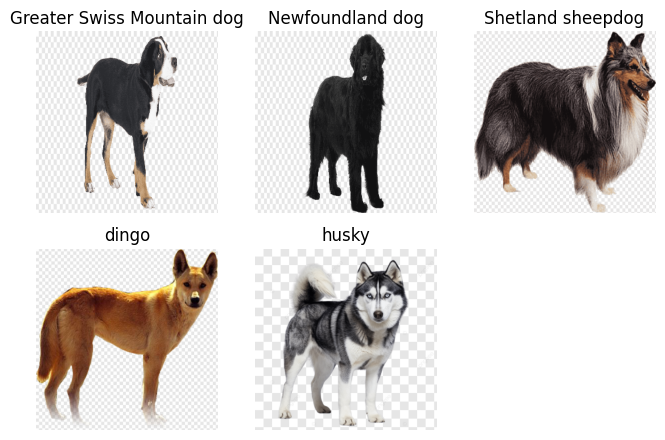

In [5]:
class_name = ['Greater Swiss Mountain dog', 'Newfoundland dog', 'Shetland sheepdog', 'dingo', 'husky']

plt.figure(figsize=(8, 8))
for i in range(5):
  image = images[i]
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image[:, :, ::-1])
  plt.title(class_name[i])
  plt.axis("off")


In [6]:
res = model.predict(input_images)
for i in res:
  print(np.argmax(i))

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
238
226
230
273
250


In [7]:
true_res = keras.applications.resnet_v2.decode_predictions(res, top=3)
for i in range(5):
  print(true_res[i])

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[('n02107574', 'Greater_Swiss_Mountain_dog', np.float32(0.7336856)), ('n02107908', 'Appenzeller', np.float32(0.10589752)), ('n02088632', 'bluetick', np.float32(0.08539948))]
[('n02105251', 'briard', np.float32(0.6852033)), ('n02111277', 'Newfoundland', np.float32(0.1439805)), ('n02099267', 'flat-coated_retriever', np.float32(0.1186142))]
[('n02105855', 'Shetland_sheepdog', np.float32(0.78666973)), ('n02106030', 'collie', np.float32(0.2112672)), ('n02106166', 'Border_collie', np.float32(0.0015806891))]
[('n02115641', 'dingo', np.float32(0.9125716)), ('n02114548', 'white_wolf', np.float32(0.05513608)), ('n02105412', 'kelpie', np.float32(0.007499532))]
[('n02110185', 'Siberian_husky', np.float32(0.57227355)), ('n02109961', 'Eskimo_dog', np.float32(0.4210411)), ('n02110063', 'malamute', np.float32(0.006663728))]


## **Задание 2. Использование обученной модели для работы со своим датасетом**

### **2.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [8]:
import tensorflow as tf
help(tf.keras.applications)

Help on package keras.applications in keras:

NAME
    keras.applications - DO NOT EDIT.

DESCRIPTION
    This file was autogenerated. Do not edit it by hand,
    since your modifications would be overwritten.

PACKAGE CONTENTS
    convnext (package)
    densenet (package)
    efficientnet (package)
    efficientnet_v2 (package)
    imagenet_utils (package)
    inception_resnet_v2 (package)
    inception_v3 (package)
    mobilenet (package)
    mobilenet_v2 (package)
    mobilenet_v3 (package)
    nasnet (package)
    resnet (package)
    resnet50 (package)
    resnet_v2 (package)
    vgg16 (package)
    vgg19 (package)
    xception (package)

FILE
    /usr/local/lib/python3.12/dist-packages/keras/applications/__init__.py




In [ ]:
# Ваш код

### **2.2. Подготовка тренировочных данных. Разделение на обучающую и тестовую выборку**

In [ ]:
# Ваш код

### **2.3. Обучение своей модели на основе предобученной модели** "*название модели, выбранной в п.2.1.*"

In [ ]:
# Ваш код

### **2.4. Визуализация процесса обучения модели**

In [ ]:
# Ваш код

### **2.5. Подготовьте набор проверочных данных (examples)**

In [ ]:
# Ваш код

### **2.6. Реализуйте графический интерфейс для взаимодействия с обученной моделью, используя [Gradio](https://www.gradio.app/guides/image-classification-in-tensorflow) или люое другое решение.**



Если выбрали Gradio, то в качестве примеров (параметр examples в Gradio), используйте изображения из списка images (п.1.2.)

In [ ]:
# Ваш код

## **Задание 3. Классификация набора пространственных данных EuroSat (для магистров)**

- Ссылка на датасет: https://github.com/phelber/eurosat

- Описание на kaggle: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

В этом задании Вам будет предоставлен набор данных EuroSat, который содержит снимки земной поверхности, снятые спутником Sentinel-2. Вам нужно будет обучить модель для классификации этих изображений на 10 классов, представляющих различные типы земного покрова.

### **3.1. Загрузка данных:**
  * [Скачайте](https://madm.dfki.de/files/sentinel/EuroSAT.zip) набор данных EuroSat
  * Разделите данные на обучающую, валидационную и тестовую выборки.



In [ ]:
# Ваш код

### **3.2. Выбор архитектуры нейронной сети:**
  * Выберите архитектуру нейронной сети, основанную на трансферном обучении, например, ResNet50, VGG16 или InceptionV3 ([полный список](https://keras.io/api/applications/)).
  * Загрузите предобученную модель выбранной архитектуры.


In [ ]:
# Ваш код

### **3.3. Дообучение модели:**
  * Добавьте к предобученной модели несколько слоев для классификации изображений EuroSat.
  * Обучите модель на обучающей выборке.

In [ ]:
# Ваш код



### **3.4. Оценка модели:**
  * Оцените производительность модели на валидационной и тестовой выборках.
  * Сравните результаты с другими архитектурами нейронных сетей.



In [ ]:
# Ваш код

### **3.5. Анализ результатов:**
  * Проанализируйте влияние различных параметров на производительность модели, таких как:
      * Количество эпох обучения
      * Размер пакета
      * Функция активации
      * Оптимизатор
      * Регуляризация

-----------------------------------------
**Ваш вывод**
-----------------------------------------
